In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_outer_ellipse(image_path):
    # 1. Load the image in grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Error: Could not load image at {image_path}")
        return

    # 2. Pre-process the image
    # Apply Gaussian blur to blur out the fine cellular mesh texture
    blurred = cv2.GaussianBlur(image, (11, 11), 0)

    # 3. Thresholding to isolate the dark elliptical region
    # We use an inverted threshold so the dark cut becomes white (255)
    # The threshold value (e.g., 20) may need slight tuning based on lighting
    _, thresh = cv2.threshold(blurred, 20, 255, cv2.THRESH_BINARY_INV)

    # Apply morphological closing to fill small gaps in the outer boundary
    kernel = np.ones((2, 2), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=4)

    # 4. Find contours
    # RETR_EXTERNAL ensures we only grab the outermost boundaries
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        print("No contours found.")
        return

    # Assume the largest dark blob is our target cut
    largest_contour = max(contours, key=cv2.contourArea)

    # 5. Fit an ellipse
    # cv2.fitEllipse requires a minimum of 5 points
    if len(largest_contour) >= 5:
        ellipse = cv2.fitEllipse(largest_contour)
        
        # Unpack the tuple returned by fitEllipse
        (center_x, center_y), (axis1, axis2), cv_angle = ellipse

        # OpenCV returns bounding box dimensions; determine major/minor axes
        major_axis = max(axis1, axis2)
        minor_axis = min(axis1, axis2)

        # OpenCV's angle is measured from the vertical (y-axis) to the major axis.
        # To find the angle relative to the horizontal (x-axis), we offset by 90 degrees.
        angle_with_x_axis = (cv_angle - 90) % 180

        # Output the 4 requested properties
        print("--- Outer Ellipse Properties ---")
        print(f"1) Center Position (x, y): ({center_x:.2f}, {center_y:.2f})")
        print(f"2) Angle with x-axis:      {angle_with_x_axis:.2f} degrees")
        print(f"3) Major Axis Length:      {major_axis:.2f} pixels")
        print(f"4) Minor Axis Length:      {minor_axis:.2f} pixels")

        # 6. Visualization
        # Convert to BGR to draw colored lines over the grayscale image
        output_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        
        # Draw the fitted ellipse in green
        cv2.ellipse(output_image, ellipse, (0, 255, 0), 2)
        
        # Draw the center point in red
        cv2.circle(output_image, (int(center_x), int(center_y)), 4, (0, 0, 255), -1)

        # Display the result using matplotlib
        plt.figure(figsize=(8, 8))
        plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
        plt.title("Detected Outer Ellipse")
        plt.axis('off')
        plt.show()

    else:
        print("The detected contour does not have enough points to fit an ellipse.")



--- Outer Ellipse Properties ---
1) Center Position (x, y): (222.64, 298.44)
2) Angle with x-axis:      14.56 degrees
3) Major Axis Length:      298.56 pixels
4) Minor Axis Length:      267.92 pixels


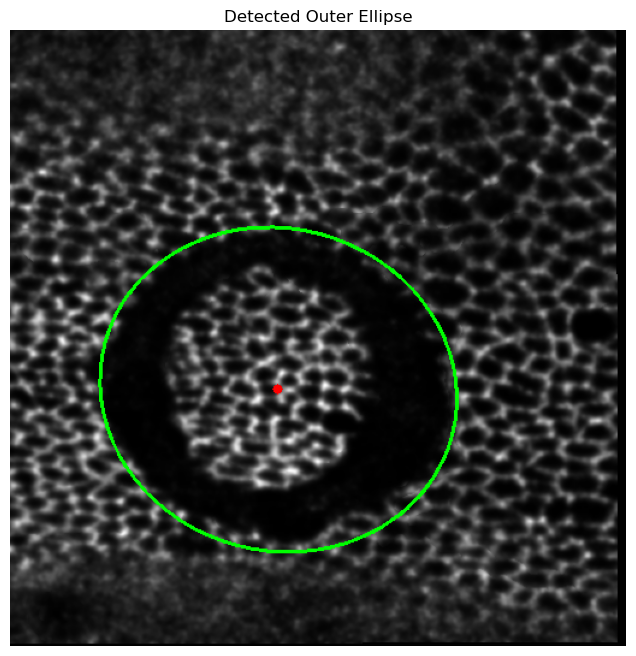

In [2]:
# Run the function
# Replace 'disc2022082301010041.tif' with your actual file name if it's in a different directory
analyze_outer_ellipse('disc2022082301010006.tif')

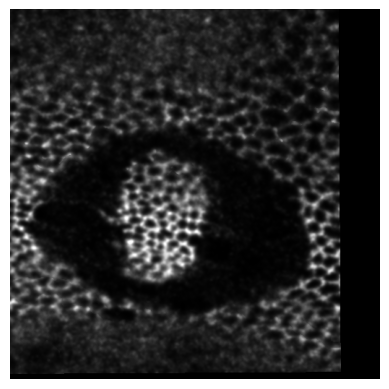

In [3]:
image_path = 'disc2022082301010041.tif'

import matplotlib.pyplot as plt

# 1. Read the image
image = plt.imread(image_path)

# 2. Plot the image
# 'cmap="gray"' ensures it doesn't apply a false-color heatmap
plt.imshow(image, cmap='gray')

# 3. Optional: Hide the x and y axes ticks for a cleaner look
plt.axis('off')

# 4. Display the plot
plt.show()

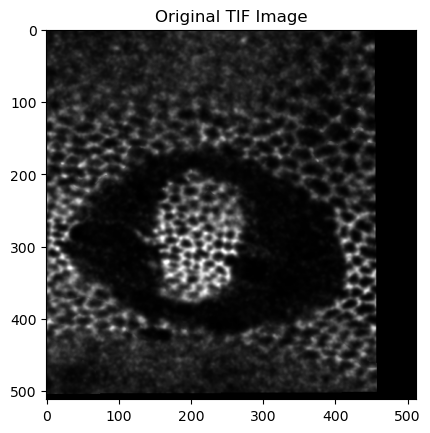

In [12]:

# 1. Read the image in grayscale using OpenCV
image_cv = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image_cv is not None:
    # 2. Plot the image
    plt.imshow(image_cv, cmap='gray')
    
    # 3. Optional: Add a title
    plt.title("Original TIF Image")
    
    # 4. Display the plot
    plt.show()
else:
    print("Could not load the image. Check the file path.")

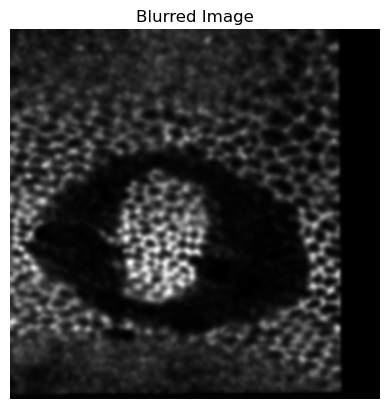

In [13]:
blurred = cv2.GaussianBlur(image_cv, (11, 11), 0)

# 1. Plot the blurred image
plt.imshow(blurred, cmap='gray')
plt.title("Blurred Image")
plt.axis('off')
plt.show()


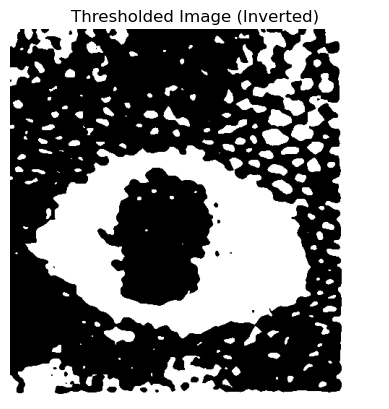

In [32]:
# 3. Thresholding to isolate the dark elliptical region
# We use an inverted threshold so the dark cut becomes white (255)
# The threshold value (e.g., 60) may need slight tuning based on lighting
_, thresh_0 = cv2.threshold(blurred, 20, 255, cv2.THRESH_BINARY_INV)

# 1. Plot the thresholded image
plt.imshow(thresh_0, cmap='gray')
plt.title("Thresholded Image (Inverted)")
plt.axis('off')
plt.show()


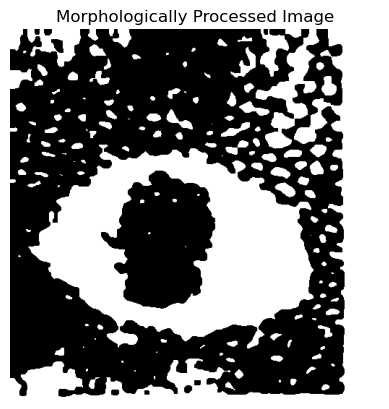

In [50]:
# Apply morphological closing to fill small gaps in the outer boundary
kernel = np.ones((2, 2), np.uint8)
thresh = cv2.morphologyEx(thresh_0, cv2.MORPH_CLOSE, kernel, iterations=4)

# 1. Plot the morphologically processed image
plt.imshow(thresh, cmap='gray')
plt.title("Morphologically Processed Image")
plt.axis('off')
plt.show()

In [51]:
# 4. Find contours
# RETR_EXTERNAL ensures we only grab the outermost boundaries
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    print("No contours found.")

# Assume the largest dark blob is our target cut
largest_contour = max(contours, key=cv2.contourArea)

In [54]:
largest_contour.shape

(682, 1, 2)

In [55]:
largest_contour

array([[[123, 160]],

       [[123, 161]],

       [[126, 164]],

       ...,

       [[133, 162]],

       [[134, 162]],

       [[134, 160]]], dtype=int32)

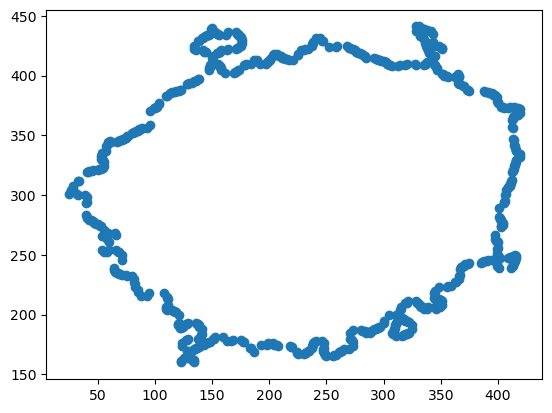

In [53]:
plt.scatter(largest_contour[:, 0, 0], largest_contour[:, 0, 1])

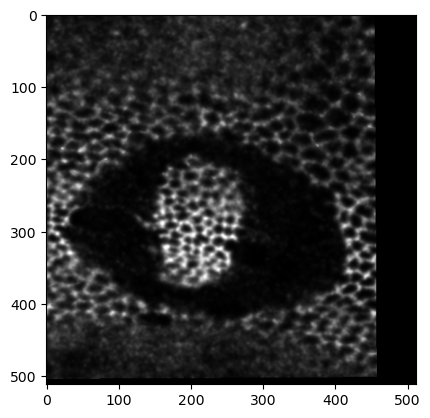

In [73]:
image = plt.imread(image_path)
plt.imshow(image, cmap='gray')

In [4]:
image.shape

(512, 512)

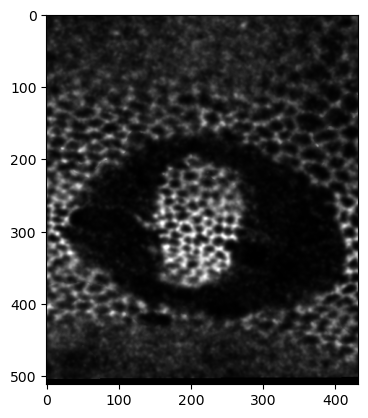

In [9]:
plt.imshow(image[:, :-80], cmap='gray')

In [24]:
X = image[:, :-80].reshape(-1,1 )
X

array([[4208],
       [4533],
       [4671],
       ...,
       [   0],
       [   0],
       [   0]], dtype=uint16)

In [25]:
from sklearn.cluster import KMeans

In [26]:
kmeans = KMeans(n_clusters=2, random_state=0).fit(X)

In [27]:
s_img = kmeans.cluster_centers_[kmeans.labels_].reshape(image[:, :-80].shape)
s_img.shape

(512, 432)

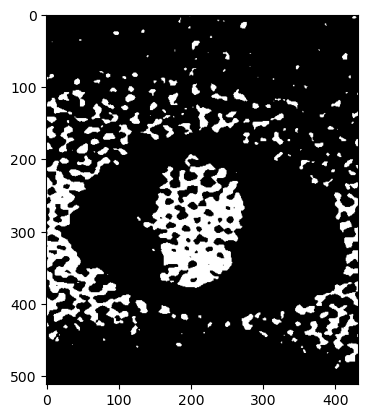

In [28]:
plt.imshow(s_img, cmap='gray')


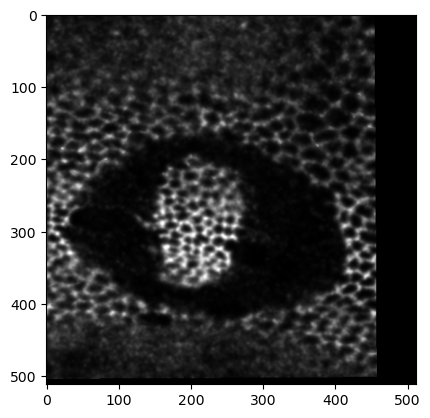

In [18]:
plt.imshow(image, cmap='gray')

In [19]:
image.min(), image.max()

(0, 65535)

In [21]:
image.shape

(512, 512)

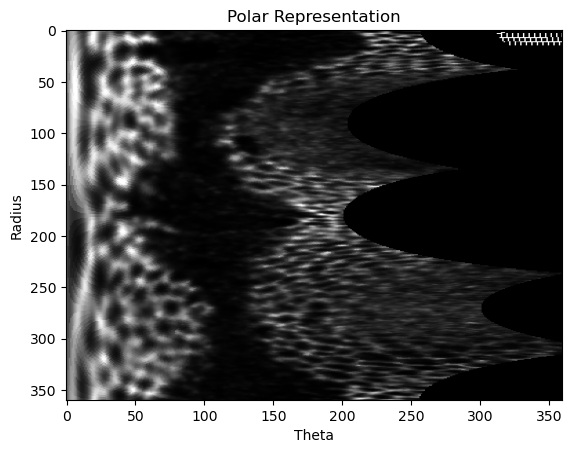

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read grayscale image
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

h, w = img.shape
center = (w//2, h//2)

# Maximum radius
max_radius = np.sqrt((w/2)**2 + (h/2)**2)

# Convert to polar coordinates
polar = cv2.warpPolar(
    img,
    (360, int(max_radius)),   # (theta bins, radius bins)
    center,
    max_radius,
    cv2.WARP_POLAR_LINEAR
)

plt.imshow(polar, aspect='auto', cmap='gray')
plt.xlabel('Theta')
plt.ylabel('Radius')
plt.title('Polar Representation')
plt.show()